# Notebook 04 — Hypothesis and Neighbour Gaps

I test whether gaps in healthy life expectancy between neighbouring areas are larger than estimate noise alone would produce. I use my derived average of male and female HLE, rather than repeating every calculation by sex. This average is not an ONS statistic. My evidence describes areas, not individual people.

I compare the full set of neighbour pairs with a noise-only simulation, report the size of the gaps in years, check spatial dependence, and identify extreme pairs using a stated rule. These comparisons show statistical patterns, not why the gaps occur.

My 1,885 shared-edge neighbour pairs have a median gap of **2.85 years** and a 90th-percentile gap of **8.05 years**. The noise-only reference median is **0.50 years**. I identify **95 big-gap pairs** under my fixed rule.

## 1. Inputs and fixed settings

I read the joined table and the same MSOA21 boundaries used for the source exploration. I use the saved HLE estimates, approximate intervals and flags. I keep my simulation settings and selection cutoffs fixed. My outputs replace the preceding files in the same Neighbours folder.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter
from IPython.display import display
%matplotlib inline


# Find the project from the notebook's current folder in either project layout.
project_folder = next(p for p in [Path.cwd(), *Path.cwd().parents]
                      if any((p / candidate).is_file() for candidate in (
                          "Data/Cleaned/Wide/msoa_wide_660.csv",
                          "data/cleaned/Wide/msoa_wide_660.csv")))

# Enforce the project environment in the working copy. A GitHub clone has no bundled .venv.
expected_environment = project_folder / "VS_CODE/.venv"
if expected_environment.is_dir():
    assert Path(sys.prefix).resolve() == expected_environment.resolve(), "Select the project virtual environment."

data_folder = project_folder / ("Data" if (project_folder / "Data").is_dir() else "data")
cleaned_folder = data_folder / ("Cleaned" if (data_folder / "Cleaned").is_dir() else "cleaned")
raw_folder = data_folder / ("Raw" if (data_folder / "Raw").is_dir() else "raw")
output_folder = cleaned_folder / "Neighbours"
figure_folder = output_folder / "figures"
assert not output_folder.is_symlink() and not figure_folder.is_symlink()
figure_folder.mkdir(parents=True, exist_ok=True)

# I clear the preceding output files in these two fixed folders.
for folder in [output_folder, figure_folder]:
    for old_file in folder.iterdir():
        assert not old_file.is_symlink(), "An output symlink needs checking."
        if old_file.is_file():
            old_file.unlink()


def read_csv(relative):
    parts = Path(relative).parts
    if parts and parts[0].casefold() == "cleaned":
        parts = (cleaned_folder.name, *parts[1:])
    return pd.read_csv(data_folder.joinpath(*parts))


# Write the file, then read it back and compare it with the table, so a failed write cannot pass unnoticed.
def save_csv(table, filename, index=False):
    with (output_folder / filename).open("w", encoding="utf-8", newline="") as stream:
        table.to_csv(stream, index=index)
    check = pd.read_csv(output_folder / filename)
    expected = table.reset_index() if index else table.reset_index(drop=True)
    pd.testing.assert_frame_equal(check, expected, check_dtype=False)


def save_figure(figure, filename):
    figure.savefig(figure_folder / filename, bbox_inches="tight")
    plt.show()
    plt.close(figure)


plt.rcParams.update({"figure.dpi":110, "savefig.dpi":150, "font.size":11,
                     "axes.spines.top":False, "axes.spines.right":False})

# Settings fixed before I look at any result. I do not change them afterwards.
EXPECTED_AREAS, EXPECTED_PAIRS = 660, 1885
SHARED_EDGE_METRES, Z_CUTOFF, BIG_GAP_QUANTILE = 1.0, 1.96, 0.95

# Fixed seeds, so the simulation and the permutations give the same numbers on every run.
NOISE_RUNS, NOISE_SEED = 10000, 20261008
MORAN_PERMUTATIONS, MORAN_SEED = 999, 20261009
settings = {"Areas":EXPECTED_AREAS, "Expected pairs":EXPECTED_PAIRS,
    "Shared boundary must exceed (metres)":SHARED_EDGE_METRES, "z cutoff":Z_CUTOFF,
    "Gap quantile":BIG_GAP_QUANTILE, "Noise runs":NOISE_RUNS, "Noise seed":NOISE_SEED,
    "Moran permutations":MORAN_PERMUTATIONS, "Moran seed":MORAN_SEED}

print(f"Python {sys.version.split()[0]} | numpy {np.__version__} | pandas {pd.__version__} | geopandas {gpd.__version__}")
print("Output folder:", output_folder.relative_to(project_folder).as_posix())
display(pd.Series(settings, name="Fixed value").to_frame())

Python 3.14.7 | numpy 2.5.3 | pandas 3.0.6 | geopandas 1.2.0
Output folder: data/cleaned/Neighbours


,Fixed value
Areas,660.00
Expected pairs,1885.00
Shared boundary must exceed (metres),1.00
z cutoff,1.96
Gap quantile,0.95
Noise runs,10000.00
Noise seed,20261008.00
Moran permutations,999.00
Moran seed,20261009.00


## 2. Check the areas and uncertainty

I require one row per area, a complete average-HLE outcome, and ordered interval bounds. I match the joined table to the boundaries by code before constructing neighbours. I project the geometries into metres. I retain the saved flags without changing their rules.

In [2]:
# Sorted by code, so every later lookup and array position is reproducible.
wide = read_csv("Cleaned/Wide/msoa_wide_660.csv").sort_values("area_code").reset_index(drop=True)
assert len(wide) == EXPECTED_AREAS and wide["area_code"].is_unique
assert wide["local_area_name"].is_unique, "Duplicate local area names would merge in Tableau"
outcome_columns = ["hle_average","hle_average_lci","hle_average_uci"]

assert wide[["area_code","local_area_name",*outcome_columns]].notna().all().all()
assert np.isfinite(wide[outcome_columns].to_numpy()).all()
assert wide["hle_average_lci"].lt(wide["hle_average"]).all()
assert wide["hle_average"].lt(wide["hle_average_uci"]).all()

flag_columns = ["student_dominated","visitor_hub","city_centre_caveat","hle_male_imputed","hle_female_imputed"]

for column in flag_columns:
    assert pd.api.types.is_bool_dtype(wide[column]) and wide[column].notna().all()

boundary_filename = "ons_msoa21_boundaries_exploratory_west_midlands.geojson"
boundary_path = next(path for path in (
    raw_folder / "Geography" / boundary_filename,
    raw_folder / "2026-10-01" / boundary_filename,
) if path.is_file())
boundaries = gpd.read_file(boundary_path)

# Identify the published MSOA code field from its values, as in Notebook 01.
boundary_code_field = next(field for field in boundaries.columns if field != "geometry"
    and boundaries[field].astype(str).str.fullmatch(r"[EW]020\d{5}").all())

assert boundaries[boundary_code_field].is_unique and len(boundaries) == EXPECTED_AREAS
assert set(boundaries[boundary_code_field]) == set(wide["area_code"])
assert boundaries.crs is not None and boundaries.geometry.notna().all()
assert boundaries.geometry.is_valid.all()

# Project to metres, so a boundary length means something.
boundaries_by_code = boundaries.set_index(boundary_code_field).to_crs(27700)
assert boundaries_by_code.crs.to_epsg() == 27700
assert "MSOA21NM" in boundaries_by_code.columns
area_table = wide.set_index("area_code")

# Standard error from the interval: full width divided by 2 × 1.96, because the interval is a 95% one.
area_table["se_average"] = (area_table["hle_average_uci"] - area_table["hle_average_lci"]) / (2 * Z_CUTOFF)
assert area_table["se_average"].gt(0).all()

print(f"I retain {len(wide):,} unique areas with complete average-HLE estimates and ordered intervals.")

I retain 660 unique areas with complete average-HLE estimates and ordered intervals.


## 3. Neighbours share an edge

I use the source-exploration definition: two MSOAs are neighbours only when their shared boundary is longer than one metre. Contact at a single corner does not count. I record each pair once, in code order, and check the expected pair count before calculating the gaps.

In [3]:
area_codes = list(boundaries_by_code.index)
shapes = boundaries_by_code.geometry.values
tree = boundaries_by_code.sindex

# Same rule as Notebook 01: a shared boundary longer than one metre, so corner-only contact is excluded.
touching = set()

for i, shape in enumerate(shapes):
    for j in tree.query(shape, predicate="intersects"):
        if i != j and shape.boundary.intersection(shapes[j].boundary).length > SHARED_EDGE_METRES:
            # Sorting the two codes records each pair once, whichever area is visited first.
            touching.add(tuple(sorted((area_codes[i], area_codes[j]))))

# The count must match Notebook 01's 1,885. If it does not, the rule has drifted and I stop.
assert len(touching) == EXPECTED_PAIRS, f"Neighbour count {len(touching)} differs from the fixed expected count {EXPECTED_PAIRS}; the rule is unchanged."
assert not (set(area_codes) - {code for pair in touching for code in pair}), "An area has no neighbours."
pairs = pd.DataFrame(sorted(touching), columns=["area_a","area_b"])
assert pairs["area_a"].lt(pairs["area_b"]).all() and not pairs.duplicated(["area_a","area_b"]).any()

# Attach each member's values to the pair, with the suffix _a or _b.
for side in ["a","b"]:
    codes = pairs["area_" + side]
    pairs["name_" + side] = codes.map(area_table["local_area_name"])
    for column in [*outcome_columns,"se_average",*flag_columns]:
        pairs[column + "_" + side] = codes.map(area_table[column])

assert pairs.notna().all().all()

print(f"I find {len(pairs):,} distinct shared-edge neighbour pairs.")
display(pairs[["name_a","name_b","hle_average_a","hle_average_b"]].head().round(2))

I find 1,885 distinct shared-edge neighbour pairs.


,name_a,name_b,hle_average_a,hle_average_b
0,Hill Hook,Four Oaks,68.35,71.05
1,Hill Hook,Sutton Coldfield North,68.35,72.05
2,Hill Hook,Shenstone,68.35,72.05
3,Four Oaks,Little Sutton,71.05,73.30
4,Four Oaks,Sutton Coldfield North,71.05,72.05


## 4. My hypothesis, before testing

**H₀:** neighbouring areas differ in HLE only by estimate noise. Their true HLE is the same, and the observed gaps come from the published uncertainty.

**H₁:** neighbouring areas differ by more than noise alone would produce.

I test this against the **whole set of neighbour pairs**. I select the extreme pairs later on purpose; they do not define this test. I express each absolute gap in years and in standard errors: `gap = |HLE_a − HLE_b|`, `se_gap = √(se_a² + se_b²)`, and `z = gap / se_gap`.

I recover each area's standard error from the average interval width divided by twice the stated cutoff. The average interval assumes independent male and female errors and is probably too narrow. The resulting z values are probably inflated, so the comparison is, if anything, too generous to H₁. I also assume independent errors between areas when calculating `se_gap`; the published marginal intervals do not supply cross-area error covariance.

In [4]:
# Gap in years, its standard error (area errors treated as independent), and the gap in standard errors.
pairs["signed_gap_years"] = pairs["hle_average_a"] - pairs["hle_average_b"]
pairs["gap_years"] = pairs["signed_gap_years"].abs()
pairs["se_gap_years"] = np.sqrt(pairs["se_average_a"]**2 + pairs["se_average_b"]**2)
pairs["z"] = pairs["gap_years"] / pairs["se_gap_years"]

# Strictly above the cutoff, to match the stated rule.
pairs["above_noise_cutoff"] = pairs["z"].gt(Z_CUTOFF)
assert np.isfinite(pairs[["gap_years","se_gap_years","z"]].to_numpy()).all()
observed_share = float(pairs["above_noise_cutoff"].mean())
median_gap = float(pairs["gap_years"].median())
p90_gap = float(pairs["gap_years"].quantile(.90))
median_z = float(pairs["z"].median())
headline = pd.DataFrame({"Measure":["Median gap","90th percentile gap","Median gap in standard errors","Share above the noise cutoff"],
    "Value":[median_gap,p90_gap,median_z,observed_share], "Unit":["years","years","standard errors","fraction of all pairs"]})

display(headline.round(3))

,Measure,Value,Unit
0,Median gap,2.850,years
1,90th percentile gap,8.050,years
2,Median gap in standard errors,3.780,standard errors
3,Share above the noise cutoff,0.698,fraction of all pairs


### Size of the observed gaps

My median neighbour gap is **2.85 years**; the 90th percentile is **8.05 years**. The median gap is **3.78 standard errors**. These describe the full set of pairs, before selecting extremes. The average interval assumes independent male and female errors and is probably too narrow, so z is probably inflated and the test is, if anything, too generous to H₁.

## 5. A noise-only comparison for the whole set

I simulate the same areas under H₀, with a common true HLE and normally distributed estimate errors scaled by each area's saved standard error. The common true value cancels when I calculate a gap. In each run I draw **one error per area**, then reuse it in every pair containing that area. This preserves the dependence caused by pairs sharing areas; I do not treat the pairs as independent tests.

I compare the observed share above the cutoff and the observed median gap with the distribution of those two summaries across the fixed simulation runs. The reference bands below are simulation ranges under H₀, not confidence intervals for the observed effect. Normal errors and the supplied standard errors are assumptions, not new measurements.

In [5]:
# Array position of each area, so a pair can look up its two members' simulated errors.
ordered_codes = area_table.index.to_list()
code_positions = {code:i for i,code in enumerate(ordered_codes)}
a_index = pairs["area_a"].map(code_positions).to_numpy()
b_index = pairs["area_b"].map(code_positions).to_numpy()
area_se = area_table["se_average"].to_numpy()
se_gap = pairs["se_gap_years"].to_numpy()

# Seeded generator, so the simulated errors are the same on every run.
rng = np.random.default_rng(NOISE_SEED)
simulated_shares = np.empty(NOISE_RUNS)
simulated_medians = np.empty(NOISE_RUNS)

# Common bin edges, so the observed and simulated histograms can be overlaid.
gap_bins = np.linspace(0, np.ceil(pairs["gap_years"].max()) + 1, 37)
z_bins = np.linspace(0, np.ceil(pairs["z"].max()) + 1, 61)
noise_gap_counts = np.zeros(len(gap_bins)-1, dtype=np.int64)
noise_z_counts = np.zeros(len(z_bins)-1, dtype=np.int64)

# Simulate in batches of 200 runs to keep memory small.
for start in range(0, NOISE_RUNS, 200):
    stop = min(start + 200, NOISE_RUNS)

    # One error per area per run, scaled by that area's own standard error. An area in several pairs reuses the same error in each, which keeps the dependence between pairs.
    errors = rng.normal(size=(stop-start, len(area_se))) * area_se
    noise_gaps = np.abs(errors[:,a_index] - errors[:,b_index])
    noise_z = noise_gaps / se_gap
    simulated_shares[start:stop] = (noise_z > Z_CUTOFF).mean(axis=1)
    simulated_medians[start:stop] = np.median(noise_gaps, axis=1)

    # Keep histogram counts rather than every simulated gap, so memory stays small.
    noise_gap_counts += np.histogram(noise_gaps, bins=gap_bins)[0]
    noise_z_counts += np.histogram(noise_z, bins=z_bins)[0]

expected_share = float(simulated_shares.mean())
noise_median_gap = float(np.median(simulated_medians))
share_reference = np.quantile(simulated_shares,[.025,.975])
median_reference = np.quantile(simulated_medians,[.025,.975])

# Under H0 the share above 1.96 is about 5% by construction. This assert checks my code, not the areas.
assert .04 < expected_share < .06, "The standard-normal noise reference needs checking."
comparison = pd.DataFrame({"Summary":["Share with z above cutoff","Median absolute gap (years)"],
    "Observed":[observed_share,median_gap], "Noise-only reference":[expected_share,noise_median_gap],
    "Noise reference 2.5th percentile":[share_reference[0],median_reference[0]],
    "Noise reference 97.5th percentile":[share_reference[1],median_reference[1]]})

display(comparison.round(4))
print(f"I simulate {NOISE_RUNS:,} runs with seed {NOISE_SEED}; I report summaries, not independent pair p-values.")

,Summary,Observed,Noise-only reference,Noise reference 2.5th percentile,Noise reference 97.5th percentile
0,Share with z above cutoff,0.6981,0.0499,0.035,0.0663
1,Median absolute gap (years),2.8500,0.5026,0.464,0.5422


I simulate 10,000 runs with seed 20261008; I report summaries, not independent pair p-values.


### Observed gaps against estimate noise

I observe **69.8%** of pairs above the cutoff, against **5.0%** under the noise-only simulation. The simulation's central reference range is 3.5–6.6%. My median gap is **2.85 years**, against a simulation reference median of **0.50 years** (reference range 0.46–0.54 years). The observed summaries are larger than the noise-only reference under the stated assumptions. I have evidence against that noise-only H₀, not a causal account of the gaps. The 5.0% under H₀ is not evidence about the areas: with the standard errors taken as given, z is standard normal under H₀ by construction, so the simulated share only confirms that my code reproduces the 1.96 cutoff. The evidence is the observed 69.8%. The probably narrow average interval makes the comparison too generous to H₁; I do not present these markers as independent pair p-values.

### Gap distribution

I overlay the pooled noise-only gaps on the observed neighbour gaps using common bin edges. Both distributions are densities, so their areas are comparable despite the different number of simulated values.

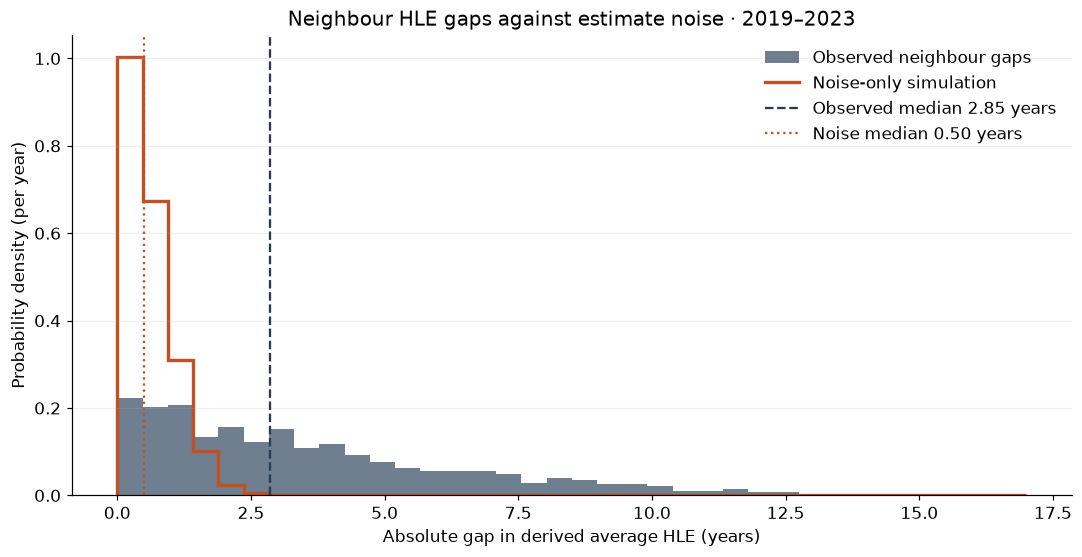

In [6]:
fig,ax = plt.subplots(figsize=(10,5.2))
ax.hist(pairs["gap_years"], bins=gap_bins, density=True, color="#243b53", alpha=.65, label="Observed neighbour gaps")

# Counts to density, so the two histograms are comparable despite different totals.
noise_density = noise_gap_counts / noise_gap_counts.sum() / np.diff(gap_bins)
ax.stairs(noise_density, gap_bins, color="#c25024", linewidth=2.2, label="Noise-only simulation")
ax.axvline(median_gap,color="#243b53",linestyle="--",label=f"Observed median {median_gap:.2f} years")
ax.axvline(noise_median_gap,color="#c25024",linestyle=":",label=f"Noise median {noise_median_gap:.2f} years")
ax.set(title="Neighbour HLE gaps against estimate noise · 2019–2023", xlabel="Absolute gap in derived average HLE (years)", ylabel="Probability density (per year)")
ax.legend(frameon=False)
ax.grid(axis="y",alpha=.2)
fig.tight_layout()
save_figure(fig,"01_gap_distribution.png")

### Gap size in standard errors

Under the stated normal-error H₀, the absolute z statistic follows a folded standard-normal distribution. I show that theoretical reference with the simulated and observed distributions. The approximate average interval affects this comparison too.

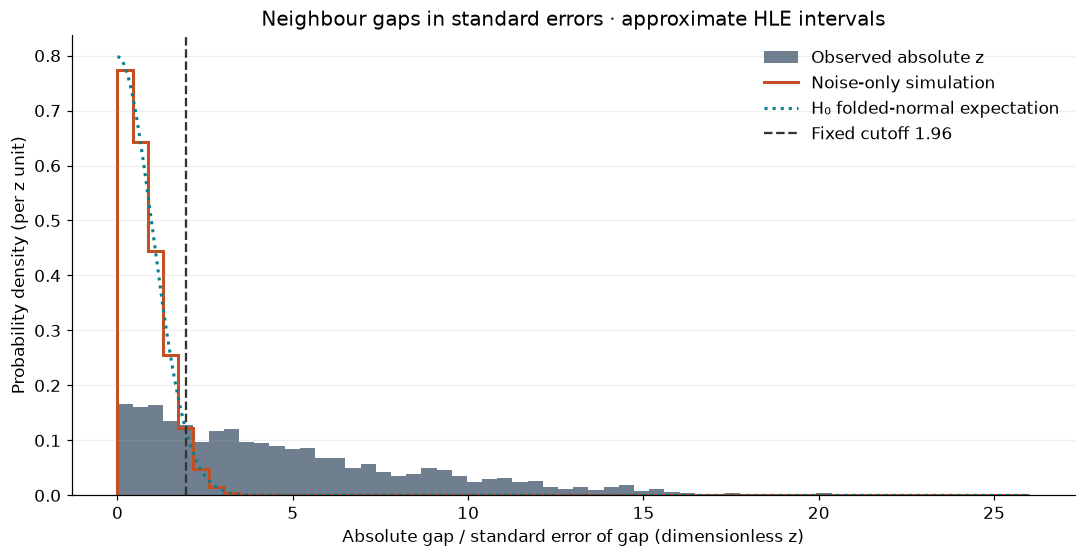

In [7]:
fig,ax = plt.subplots(figsize=(10,5.2))
ax.hist(pairs["z"],bins=z_bins,density=True,color="#243b53",alpha=.65,label="Observed absolute z")
noise_density = noise_z_counts / noise_z_counts.sum() / np.diff(z_bins)
ax.stairs(noise_density,z_bins,color="#c25024",linewidth=2,label="Noise-only simulation")

# Theoretical density of the absolute value of a standard normal: the H0 expectation for |z|.
x = np.linspace(0,z_bins[-1],1000)
ax.plot(x,np.sqrt(2/np.pi)*np.exp(-x*x/2),color="#087f8c",linestyle=":",linewidth=2,label="H₀ folded-normal expectation")
ax.axvline(Z_CUTOFF,color="#333333",linestyle="--",label=f"Fixed cutoff {Z_CUTOFF}")
ax.set(title="Neighbour gaps in standard errors · approximate HLE intervals",xlabel="Absolute gap / standard error of gap (dimensionless z)",ylabel="Probability density (per z unit)")
ax.legend(frameon=False)
ax.grid(axis="y",alpha=.2)
fig.tight_layout()
save_figure(fig,"02_z_distribution.png")

## 6. Spatial dependence

I use the same neighbours to form a symmetric adjacency matrix, then give each area's neighbours equal weights summing to one. Moran's I compares centred HLE with the weighted mean of its neighbours' centred HLE. Positive values indicate that neighbouring areas tend to resemble each other.

I implement `I = (n / sum(W)) × (cᵀ W c) / (cᵀ c)` with NumPy. I compare it with random permutations of the observed HLE values across the fixed map; this checks spatial arrangement and is separate from my estimate-noise hypothesis. My formula and row standardisation follow the [PySAL Moran implementation](https://github.com/pysal/esda/blob/main/esda/moran.py), without adding a spatial-statistics package. I state a positive-association permutation reference, not independent tests for each area.

,Value
Observed Moran's I,0.5765
Permutation mean,-0.0005
Random-arrangement expectation,-0.0015
Permutation lower reference,-0.0445
Permutation upper reference,0.0484
Positive-association permutation reference,0.0010


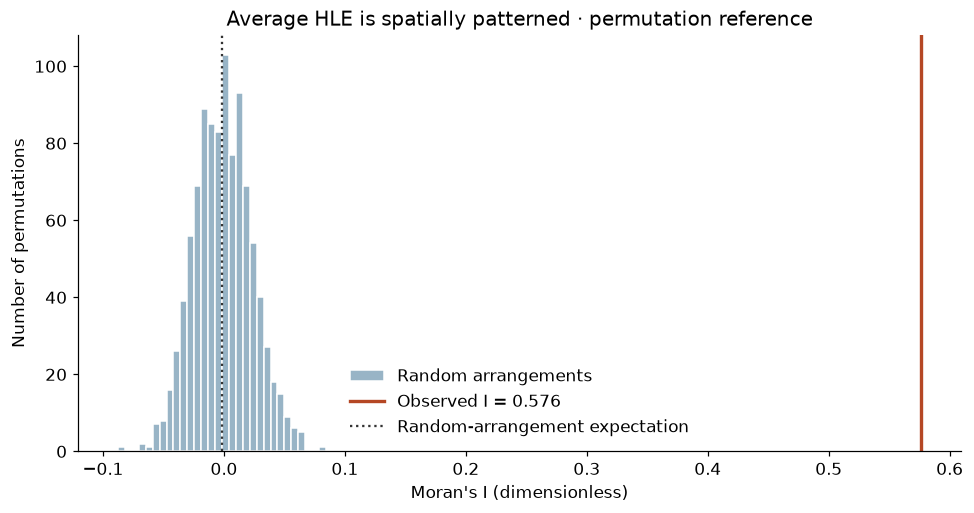

In [8]:
n_areas = len(area_table)

# Symmetric 0/1 matrix: entry (i, j) is 1 when areas i and j are neighbours.
adjacency = np.zeros((n_areas,n_areas),dtype=float)
adjacency[a_index,b_index] = adjacency[b_index,a_index] = 1
assert np.array_equal(adjacency,adjacency.T) and np.diag(adjacency).sum() == 0
assert adjacency.sum() == 2 * len(pairs)
degree = adjacency.sum(axis=1)
assert (degree > 0).all()

# Row-standardise: each area's neighbours share a total weight of one.
weights = adjacency / degree[:,None]
assert np.allclose(weights.sum(axis=1),1)
values = area_table["hle_average"].to_numpy()
centred = values - values.mean()
denominator = float(centred @ centred)
assert denominator > 0

# Moran's I = (n / sum of weights) × (centred values · weighted neighbour values) / sum of squared centred values.
moran_i = float(n_areas / weights.sum() * (centred @ weights @ centred) / denominator)

# I cross-check the numerator by summing the two directed weights of each undirected pair.
edge_numerator = np.sum(centred[a_index] * centred[b_index] * (1/degree[a_index] + 1/degree[b_index]))
assert np.isclose(moran_i,n_areas / weights.sum() * edge_numerator / denominator)

# Shuffle the HLE values across the fixed map. This keeps the neighbour structure and breaks any spatial pattern.
moran_rng = np.random.default_rng(MORAN_SEED)
permutation_i = np.empty(MORAN_PERMUTATIONS)

for start in range(0,MORAN_PERMUTATIONS,100):
    stop = min(start+100,MORAN_PERMUTATIONS)
    shuffled = np.stack([moran_rng.permutation(centred) for _ in range(stop-start)])
    permutation_i[start:stop] = n_areas / weights.sum() * np.sum(shuffled * (shuffled @ weights.T),axis=1) / denominator

# One-sided: the share of shuffles at least as clustered as the observed map. The +1 counts the observed value itself.
moran_positive_reference = float((1 + np.sum(permutation_i >= moran_i)) / (MORAN_PERMUTATIONS + 1))
moran_reference = np.quantile(permutation_i,[.025,.975])

display(pd.Series({"Observed Moran's I":moran_i,"Permutation mean":permutation_i.mean(),
    "Random-arrangement expectation":-1/(n_areas-1),"Permutation lower reference":moran_reference[0],
    "Permutation upper reference":moran_reference[1],"Positive-association permutation reference":moran_positive_reference}).round(4).to_frame("Value"))

fig,ax = plt.subplots(figsize=(9,4.8))
ax.hist(permutation_i,bins=30,color="#98b4c6",edgecolor="white",label="Random arrangements")
ax.axvline(moran_i,color="#b54724",linewidth=2.2,label=f"Observed I = {moran_i:.3f}")
ax.axvline(-1/(n_areas-1),color="#333333",linestyle=":",label="Random-arrangement expectation")
ax.set(title="Average HLE is spatially patterned · permutation reference",xlabel="Moran's I (dimensionless)",ylabel="Number of permutations")
ax.legend(frameon=False)
fig.tight_layout()
save_figure(fig,"03_moran_permutation.png")

### What spatial dependence means

My average-HLE Moran's I is **0.576**, compared with a permutation mean of **-0.001**. The positive-association permutation reference is **0.001**, using 999 permutations. Neighbouring areas resemble each other across the map even though some individual gaps are large. I need to account for this spatial dependence in statistical comparisons and keep neighbouring areas together when validating models, rather than treating each area or pair as independent.

## 7. My big-gap rule, before selecting pairs

I define a big-gap pair as a neighbour pair whose gap is at or above the empirical 95th percentile of all neighbour gaps **and** whose z exceeds the fixed cutoff. This selects the largest 5% by a quantile threshold; I retain ties at that threshold. I keep this rule fixed after looking at the results.

I deliberately select extreme pairs. Any finding about this selected set applies to those pairs, not to all neighbours. The extremes contain some of the largest noise contributions too, so selection tends to overstate the typical gap.

I retain every pair and flag whether either member is student-dominated, a visitor hub, has an imputed estimate, or has the city-centre caveat. Flags do not remove pairs.

In [9]:
# The 95th-percentile gap over all 1,885 pairs, fixed before any pair is selected.
gap_threshold = float(pairs["gap_years"].quantile(BIG_GAP_QUANTILE))

# At or above the threshold keeps ties. The z condition removes gaps that noise alone could produce.
pairs["big_gap_pair"] = pairs["gap_years"].ge(gap_threshold) & pairs["above_noise_cutoff"]

# A flag counts for the pair if either member has it.
for column in ["student_dominated","visitor_hub","city_centre_caveat"]:
    pairs[column + "_either"] = pairs[column+"_a"] | pairs[column+"_b"]

# Imputation is recorded per sex, so either sex in either area counts.
pairs["imputed_either"] = pairs[["hle_male_imputed_a","hle_female_imputed_a","hle_male_imputed_b","hle_female_imputed_b"]].any(axis=1)

# Sort by gap, then by codes, so tied gaps always come out in the same order.
big_pairs = pairs.loc[pairs["big_gap_pair"]].sort_values(["gap_years","area_a","area_b"],ascending=[False,True,True]).reset_index(drop=True)

# Stop for a decision if the unchanged rule gives too few or too many pairs.
assert 10 <= len(big_pairs) <= 150, f"The unchanged rule selects {len(big_pairs)} pairs; the stated decision range is 10–150."
flag_summary = pd.DataFrame({"Flag":["Student-dominated member","Visitor-hub member","Imputed estimate","City-centre caveat"],
    "Big-gap pairs with flag":[int(big_pairs[c].sum()) for c in ["student_dominated_either","visitor_hub_either","imputed_either","city_centre_caveat_either"]]})

print(f"My fixed gap threshold is {gap_threshold:.3f} years; I retain {len(big_pairs)} big-gap pairs.")
display(flag_summary)

# The ten largest gaps over all pairs, not only the selected ones, to compare with the stated range of gaps.
top10 = pairs.nlargest(10,"gap_years")
top10_display = pd.DataFrame({"Area A":top10["name_a"],"Average HLE A [interval]":top10.apply(lambda r:f"{r.hle_average_a:.2f} [{r.hle_average_lci_a:.2f}, {r.hle_average_uci_a:.2f}]",axis=1),
    "Area B":top10["name_b"],"Average HLE B [interval]":top10.apply(lambda r:f"{r.hle_average_b:.2f} [{r.hle_average_lci_b:.2f}, {r.hle_average_uci_b:.2f}]",axis=1),
    "Gap (years)":top10["gap_years"].round(2),"z":top10["z"].round(2)})

display(top10_display.reset_index(drop=True))

My fixed gap threshold is 9.590 years; I retain 95 big-gap pairs.


,Flag,Big-gap pairs with flag
0,Student-dominated member,2
1,Visitor-hub member,3
2,Imputed estimate,3
3,City-centre caveat,0


,Area A,Average HLE A [interval],Area B,Average HLE B [interval],Gap (years),z
0,New Oscott,"70.45 [69.51, 71.39]",Perry Common College Road,"54.60 [53.75, 55.45]",15.85,24.48
1,Fox Hollies,"56.35 [55.47, 57.23]",Ulverley Green,"72.00 [70.83, 73.17]",15.65,20.96
2,Druids Heath,"54.20 [53.05, 55.35]",Hollywood,"69.75 [68.25, 71.25]",15.55,16.12
3,Frankley,"55.80 [54.83, 56.77]",Dodford,"70.95 [69.99, 71.91]",15.15,21.73
4,Druids Heath,"54.20 [53.05, 55.35]",Wythall,"69.35 [68.31, 70.39]",15.15,19.11
5,Hawkesley,"56.40 [55.37, 57.43]",Alvechurch,"71.10 [70.12, 72.08]",14.70,20.35
6,Kingstanding North,"69.15 [68.01, 70.29]",Perry Common College Road,"54.60 [53.75, 55.45]",14.55,20.08
7,Lye,"58.90 [57.73, 60.07]",Hagley,"73.25 [72.17, 74.33]",14.35,17.70
8,Warndon West,"55.30 [54.03, 56.57]",Warndon East,"69.45 [67.91, 70.99]",14.15,13.88
9,Willenhall,"55.25 [54.19, 56.31]",Wolston,"69.15 [68.03, 70.27]",13.90,17.68


### The selected pairs and flags

The empirical gap threshold is **9.59 years**. My rule selects **95 pairs**, of which **30** include a Birmingham area. The largest gap is **15.85 years**, between **New Oscott** and **Perry Common College Road**. The ten largest gaps run from **13.90 to 15.85 years**, so the most extreme neighbours differ by about 14 to 16 years. This uses my combined-sex average, so it need not equal the largest male or female gap. I retain all selected pairs; flags identify caveats rather than exclusions. The selected extremes do not represent the typical neighbour gap.

## 8. Map of the selected neighbours

I show the full study coverage and a Birmingham detail at the same map projection and HLE colour scale. I identify Birmingham from the original MSOA names. I outline in red every area that belongs to a selected pair; the pair table, not the map, records which areas are paired. The black outline marks Birmingham. The colour is my derived average HLE, not an ONS combined-sex statistic.

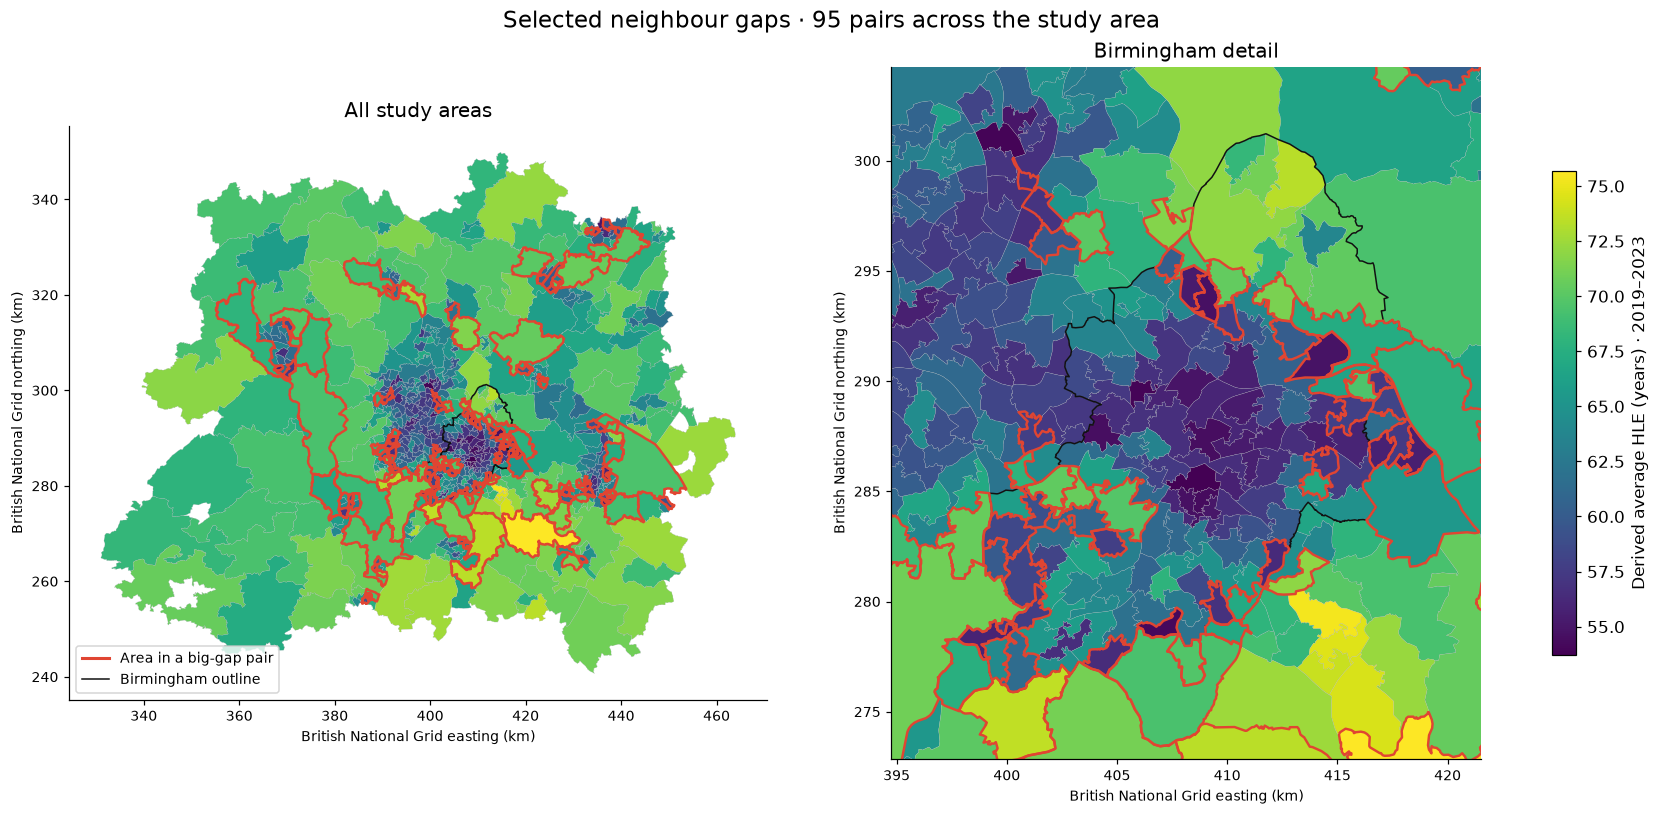

138 areas belong to the 95 selected pairs; 30 selected pairs include at least one Birmingham area; all selected pairs remain in the tables.


In [10]:
# Attach each area's HLE to its geometry. validate checks that no area is duplicated or lost.
map_areas = boundaries_by_code.join(area_table[["hle_average"]],validate="one_to_one")

# Birmingham is identified from the original MSOA name.
birmingham = map_areas.loc[map_areas["MSOA21NM"].str.startswith("Birmingham ")]
assert not birmingham.empty
birmingham_outline = birmingham.geometry.union_all()

# Outline every area in a selected pair. Lines between interior points would cross unrelated areas.
selected_codes = sorted(set(big_pairs["area_a"]) | set(big_pairs["area_b"]))
selected_areas = map_areas.loc[selected_codes]
birmingham_codes = set(birmingham.index)
birmingham_big_count = int((big_pairs["area_a"].isin(birmingham_codes) | big_pairs["area_b"].isin(birmingham_codes)).sum())

# constrained layout keeps the shared colour bar from overlapping the maps.
fig,axes = plt.subplots(1,2,figsize=(15,7.3),layout="constrained")

# One colour scale for both panels, so the colours mean the same in each.
colour_min,colour_max = map_areas["hle_average"].min(),map_areas["hle_average"].max()

for ax,title in zip(axes,["All study areas","Birmingham detail"]):
    map_areas.plot(column="hle_average",cmap="viridis",vmin=colour_min,vmax=colour_max,ax=ax,edgecolor="#a9b0b4",linewidth=.15)
    gpd.GeoSeries([birmingham_outline],crs=map_areas.crs).boundary.plot(ax=ax,color="#111111",linewidth=1.0)
    selected_areas.boundary.plot(ax=ax,color="#e04532",linewidth=1.6)
    ax.set(title=title,xlabel="British National Grid easting (km)",ylabel="British National Grid northing (km)")
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x,_:f"{x/1000:.0f}"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x,_:f"{x/1000:.0f}"))
    ax.tick_params(labelsize=9)
    ax.set_aspect("equal")

# Zoom the second panel to Birmingham plus a margin; the first panel keeps the full extent.
minx,miny,maxx,maxy = birmingham.total_bounds
margin = .12 * max(maxx-minx,maxy-miny)
axes[1].set_xlim(minx-margin,maxx+margin);axes[1].set_ylim(miny-margin,maxy+margin)
axes[0].legend(handles=[Line2D([0],[0],color="#e04532",lw=2,label="Area in a big-gap pair"),Line2D([0],[0],color="#111111",lw=1,label="Birmingham outline")],loc="lower left",frameon=True,fontsize=9)
scalar = plt.cm.ScalarMappable(norm=plt.Normalize(colour_min,colour_max),cmap="viridis")
fig.colorbar(scalar,ax=axes,shrink=.7,label="Derived average HLE (years) · 2019–2023")
fig.suptitle(f"Selected neighbour gaps · {len(big_pairs)} pairs across the study area",fontsize=15)
save_figure(fig,"04_big_gap_neighbours_map.png")

print(f"{len(selected_codes)} areas belong to the {len(big_pairs)} selected pairs; {birmingham_big_count} selected pairs include at least one Birmingham area; all selected pairs remain in the tables.")

## 9. One check against the male and female figures

I use the two sexes only here. Among pairs whose average-HLE gap exceeds the noise cutoff, I count how often the male and female gaps point in the same direction. This is a direction check, not another hypothesis test or a repeat of the full analysis.

In [11]:
above_noise = pairs.loc[pairs["above_noise_cutoff"]]

# Sign of the gap in each sex. Equal values give zero, which is not counted as the same direction.
male_direction = np.sign(above_noise["area_a"].map(area_table["hle_male"]) - above_noise["area_b"].map(area_table["hle_male"]))
female_direction = np.sign(above_noise["area_a"].map(area_table["hle_female"]) - above_noise["area_b"].map(area_table["hle_female"]))
same_direction = int(((male_direction == female_direction) & male_direction.ne(0)).sum())

print(f"Male and female HLE gaps point in the same direction in {same_direction:,} of {len(above_noise):,} pairs above the noise cutoff.")

Male and female HLE gaps point in the same direction in 1,302 of 1,316 pairs above the noise cutoff.


### Direction check

Male and female gaps point in the same direction in **1,302 of 1,316 pairs** above the average-HLE noise cutoff. I report this count as a check on the combined outcome, without separate sex-specific tests.

## 10. Saved pair tables and definitions

I save all neighbour pairs, the selected subset, the headline summaries and a short column dictionary in one fixed folder. Pair codes retain their alphabetical order even when a table is sorted by gap size. I keep numeric values unrounded in the files and check each CSV by reading it back.

In [12]:
# Every number saved here is the one computed above, so the files and the notebook cannot disagree.
summary = {"area_count":len(wide),"pair_count":len(pairs),"median_gap_years":median_gap,
    "p90_gap_years":p90_gap,"median_z":median_z,"observed_above_noise_count":int(pairs["above_noise_cutoff"].sum()),
    "observed_above_noise_share":observed_share,"noise_expected_share":expected_share,
    "noise_share_reference_lower":float(share_reference[0]),"noise_share_reference_upper":float(share_reference[1]),
    "noise_median_gap_years":noise_median_gap,"noise_median_reference_lower":float(median_reference[0]),
    "noise_median_reference_upper":float(median_reference[1]),"noise_runs":NOISE_RUNS,"noise_seed":NOISE_SEED,
    "moran_i":moran_i,"moran_permutation_mean":float(permutation_i.mean()),"moran_positive_permutation_reference":moran_positive_reference,
    "moran_permutations":MORAN_PERMUTATIONS,"moran_seed":MORAN_SEED,
    "gap_quantile":BIG_GAP_QUANTILE,"gap_threshold_years":gap_threshold,"z_cutoff":Z_CUTOFF,
    "big_gap_pair_count":len(big_pairs),"largest_gap_years":float(pairs["gap_years"].max()),
    "largest_pair_names":[str(top10.iloc[0]["name_a"]),str(top10.iloc[0]["name_b"])],
    "big_gap_flag_counts":{row["Flag"]:int(row["Big-gap pairs with flag"]) for row in flag_summary.to_dict("records")},
    "birmingham_big_gap_pair_count":birmingham_big_count,"same_sex_direction_count":same_direction,
    "sex_check_pair_count":len(above_noise),"output_folder":output_folder.relative_to(project_folder).as_posix(),
    "outcome":"Derived mean of male and female HLE; approximate interval assumes independent sex errors"}
save_csv(pairs,"neighbour_pairs.csv")
save_csv(big_pairs,"big_gap_pairs.csv")

# Numbers only; unit is read from the key name, with counts and seeds overridden.
summary_rows=[]

for key,value in summary.items():
    if isinstance(value,(int,float)):
        unit = "years" if "years" in key else "dimensionless"
        if key.endswith("count") or key in ["noise_runs","moran_permutations"]:unit="count"
        if "seed" in key:unit="seed"
        summary_rows.append({"metric":key,"value":value,"unit":unit})

save_csv(pd.DataFrame(summary_rows),"neighbour_summary.csv")

# One row per column of the pair table, so the saved file can be read without guessing what a column means.
dictionary=[]

for column in pairs:
    unit="boolean" if pd.api.types.is_bool_dtype(pairs[column]) else "text"

    if column in ["area_a","area_b"]:meaning="MSOA21 code of pair member; area_a is alphabetically before area_b"
    elif column.startswith("name_"):meaning="Familiar local label of pair member"
    elif column.startswith("hle_average_lci_"):meaning="Lower bound of approximate average-HLE interval; independent sex-error assumption"
    elif column.startswith("hle_average_uci_"):meaning="Upper bound of approximate average-HLE interval; independent sex-error assumption"
    elif column.startswith("hle_average_"):meaning="Derived average of male and female HLE, not an ONS statistic"
    elif column.startswith("se_average_"):meaning="Area standard error from its average-HLE interval width divided by twice the z cutoff"
    elif column=="signed_gap_years":meaning="Average HLE of area_a minus average HLE of area_b"
    elif column=="gap_years":meaning="Absolute difference in derived average HLE"
    elif column=="se_gap_years":meaning="Square root of summed squared area standard errors; assumes independent errors between areas"
    elif column=="z":meaning="Absolute average-HLE gap divided by its approximate standard error"
    elif column=="above_noise_cutoff":meaning="z strictly exceeds the fixed cutoff; a pair marker, not an independent pair test"
    elif column=="big_gap_pair":meaning="Gap at or above the empirical 95th percentile and z above the fixed cutoff; threshold ties retained"
    elif column=="imputed_either":meaning="Either area has a male or female estimate with a saved imputation flag"
    else:
        base=column[:-2] if column.endswith(("_a","_b")) else column.removesuffix("_either")
        meaning={"student_dominated":"Saved student-dominated flag; area retained","visitor_hub":"Saved visitor-hub flag; no pair removed","city_centre_caveat":"Saved Birmingham city-centre caveat","hle_male_imputed":"Saved male estimate imputation flag","hle_female_imputed":"Saved female estimate imputation flag"}[base]
        meaning += "; either member" if column.endswith("_either") else "; named pair member"

    if column.startswith(("hle_average_","se_average_")) or column.endswith("_years"):unit="years"

    if column=="z":unit="standard errors (dimensionless)"

    dictionary.append({"column":column,"unit":unit,"definition":meaning,"source":"Saved joined table and MSOA21 boundary neighbours; calculated in this notebook"})

save_csv(pd.DataFrame(dictionary),"neighbour_data_dictionary.csv")

# The dictionary must describe exactly the columns that were saved.
assert set(pd.read_csv(output_folder / "neighbour_data_dictionary.csv")["column"]) == set(pairs.columns)
assert len(pd.read_csv(output_folder / "neighbour_pairs.csv")) == EXPECTED_PAIRS

with (output_folder / "results_summary.json").open("w",encoding="utf-8") as stream:
    json.dump(summary,stream,indent=2,ensure_ascii=False)

# Read the JSON back and compare it with the dictionary written.
assert json.loads((output_folder / "results_summary.json").read_text()) == summary

print("I save and read back the neighbour tables, summary and dictionary; the figures are embedded above.")

I save and read back the neighbour tables, summary and dictionary; the figures are embedded above.


## What I found

My typical neighbour gap is **2.85 years**, with the larger end of the distribution reaching a 90th percentile of **8.05 years**. The noise-only reference produces much smaller gaps under its assumptions. Spatial resemblance and large local contrasts coexist: Moran's I is **0.576**, and my fixed extreme-pair rule identifies **95 pairs**.

I treat the derived average-HLE interval as approximate. Its independent male/female error assumption probably narrows it and inflates z; cross-area error covariance is unavailable. Shared areas make pair summaries dependent, which is why I simulate errors at area level and avoid independent pair p-values. My extreme-pair selection overstates the typical gap, and the permutation reference tests map arrangement rather than estimate noise. All results concern area-level HLE estimates for the pooled source period; none establish causes or individual outcomes.